In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.hamiltonian import Lattice, Hamiltonian
from scripts.self_consistency import bdg_sc

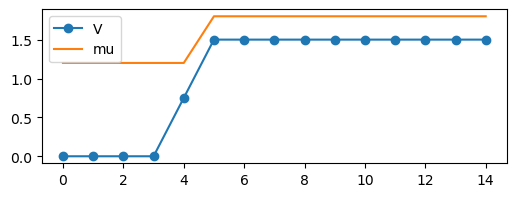

In [2]:
widthN = 5
widthP = 10

X, Y = widthN+widthP, 50
lattice = Lattice(X, Y)
t = 1
T = 0.01
muN = 1.2 * t
muP = 1.8 * t
mu = np.zeros(lattice.X)
mu[:widthN] = muN
mu[widthN:] = muP

U = None
V_prime = None

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)
V[:widthN] = 0 
V[widthN-1] = V0/2

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, label='mu')
plt.legend()

In [3]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.1, -0.1, 0.1j, -0.1j])

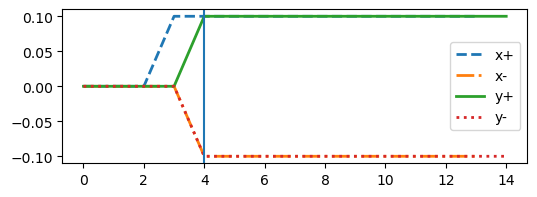

In [4]:
plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(H.F0, label="F0")
if V is not None:
    plt.plot(np.real(H.F_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.F_xmin), label="x-", linestyle='-.', lw=2)
    plt.plot(np.imag(H.F_yplus), label="y+", linestyle='-', lw=2)
    plt.plot(np.imag(H.F_ymin), label="y-", linestyle=':', lw=2)
if V_prime is not None:
    plt.plot(np.real(H.Fuu_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.Fuu_xmin), label="x-", linestyle='-.', lw=2)
    plt.plot(np.imag(H.Fuu_yplus), label="y+", linestyle='-', lw=2)
    plt.plot(np.imag(H.Fuu_ymin), label="y-", linestyle=':', lw=2)
plt.legend()
plt.axvline(widthN-1)

In [5]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, atol=1e-6, rtol=1e-3, maxiter=100, verbose=True, temperature=T)


F0:
Absolute error: 3.237710721868554e-16
Relative error: 0.0003237710721868554
Average old: 0j
Average: (-3.2544448020991074e-18+0j)
F_xplus:
Absolute error: 0.09095619005289315
Relative error: 20656435566.828884
Average old: (0.07857142857142857+0j)
Average: (0.07938472042793328+0j)
F_xmin:
Absolute error: 0.06651972097246336
Relative error: 37051561127.308685
Average old: (-0.07142857142857142+0j)
Average: (-0.07938472042793321+0j)
F_yplus:
Absolute error: 0.1239891448643569
Relative error: 77073746897.56207
Average old: 0.07333333333333333j
Average: (-2.7765204427597464e-18+0.10233867367155555j)
F_ymin:
Absolute error: 0.1239891448643569
Relative error: 77073746897.56207
Average old: -0.07333333333333333j
Average: (-2.7765204427597464e-18-0.10233867367155555j)
Fuu_xplus:
Absolute error: 3.914225812217602e-17
Relative error: 3.9142258122176024e-05
Average old: 0j
Average: (5.122550942273595e-18+0j)
Fuu_xmin:
Absolute error: 5.953709508697896e-17
Relative error: 5.953709508697897e-05

In [6]:
F_yplus = H.Fuu_yplus + H.Fdd_yplus 
F_ymin = H.Fuu_ymin + H.Fdd_ymin
F_xplus = np.zeros_like(F_yplus)
F_xmin = np.zeros_like(F_yplus)
F_xplus[:-1] = H.Fuu_xplus + H.Fdd_xplus
F_xmin[1:]  = H.Fuu_xmin + H.Fdd_xmin

F0 = H.F0

F_swave2 = (F_xplus + F_xmin + F_yplus + F_ymin) / 4
F_dwave2 = (F_xplus + F_xmin - F_yplus - F_ymin) / 4
F_px2 = (F_xplus - F_xmin) / 2
F_py2 = (F_yplus - F_ymin) / 2

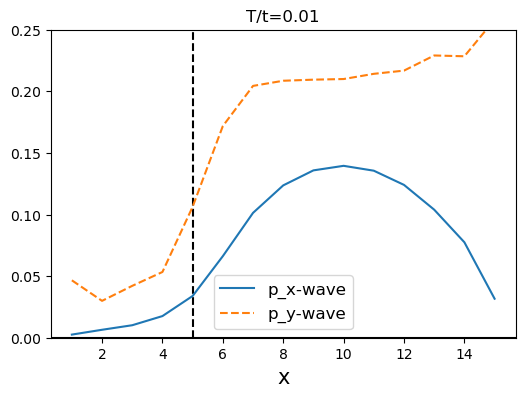

In [9]:
x = np.arange(1, widthN + widthP + 1)

fig, axs = plt.subplots(1, 1, figsize=(6, 4))
axs.set_title(f"T/t={T}")
axs.axhline(0, color = 'black')
axs.axvline(widthN, color='black', linestyle='--')
axs.plot(x, np.real(F_px), label="p_x-wave")
axs.plot(x, np.imag(F_py), "--", label="p_y-wave")
axs.set_xlabel("x", fontsize=15)
# axs.set_xlim(20, 45)
axs.set_ylim(0, 0.25)
axs.legend(fontsize=12, loc="best")
plt.show()
# plt.savefig('../figures/NP.pdf')
# print(F_px[40])

True
True
True


C:\Users\emoeu\AppData\Local\Temp\ipykernel_17592\15826088.py:12: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.imshow(M)
C:\Users\emoeu\AppData\Local\Temp\ipykernel_17592\15826088.py:12: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.imshow(M)


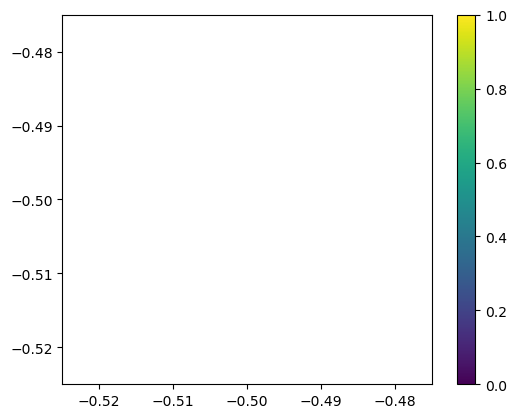

In [10]:
import matplotlib.pyplot as plt
import numpy as np

from scripts.utils import is_hermitian
ky_list = np.linspace(np.pi/50, np.pi, 50)
M = np.real(H.build_H_kindep())[120:128, 120:128]

print(is_hermitian(H.build_H_kindep()))
print(is_hermitian(H.build_H_k0()))
print(is_hermitian(H.build_H_k(np.pi)))

plt.imshow(M)
plt.colorbar()

for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        plt.text(j, i, f"{M[i, j]:.2f}",
                 ha='center', va='center', color='white')

plt.show()

In [11]:
from joblib import Parallel, delayed
from tqdm.auto import tqdm
import copy

In [17]:
T_list = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.25 + 1e-12, 0.01),
    np.arange(0.26, 0.37 + 1e-12, 0.001),
    np.arange(0.38, 0.40 + 1e-12, 0.01)
])

H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.01, -0.01, 0.01j, -0.01j])

def run_T(T):
    H_local = copy.deepcopy(H)
    F_swave, F_dwave, F_px, F_py = bdg_sc(
        H_local, rtol=0.01, atol=1e-4, maxiter=10000, verbose=False, temperature=T
    )
    return (
        np.mean(F_px),#[widthN:]),
        np.mean(F_py),#[widthN:]),
        np.mean(F_swave),#[widthN:]),
        np.mean(F_dwave),#[widthN:]),
    )

results = Parallel(n_jobs=-1)(
    delayed(run_T)(T) for T in tqdm(T_list)
)

F_px_arr, F_py_arr, F_swave_arr, F_dwave_arr = map(np.array, zip(*results))

  0%|          | 0/148 [00:00<?, ?it/s]

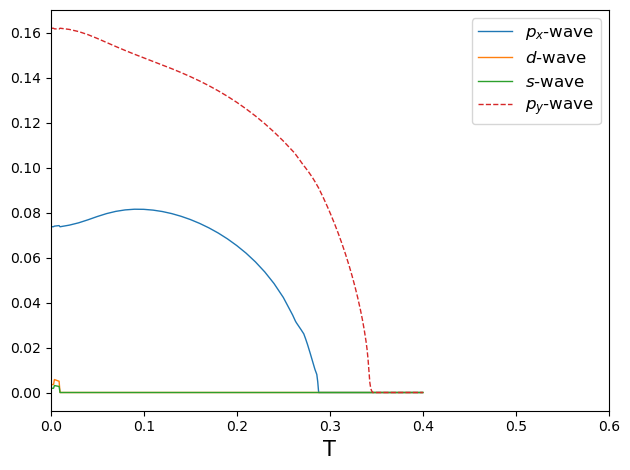

In [18]:
plt.figure(1)
plt.clf()
plt.plot(T_list, np.real(F_px_arr), linewidth=1, label=r"$p_x$-wave")
plt.plot(T_list, np.abs(F_dwave_arr), linewidth=1, label=r"$d$-wave")
plt.plot(T_list, np.abs(F_swave_arr), linewidth=1, label=r"$s$-wave")

plt.plot(T_list, np.imag(F_py_arr), "--", linewidth=1, label=r"$p_y$-wave")
# plt.ylim(0,0.3)
plt.xlim(0,0.6)
plt.xlabel("T", fontsize=15)
plt.legend(loc="best", fontsize=12)
plt.tight_layout()
plt.show()
